<a href="https://colab.research.google.com/github/AslesaLamsal/AI-and-Machine-Learning/blob/main/Week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Building Fully Connected Neural Networks for Devnagari **

**Handwritten Digit Classification.**

In [ ]:
zip_path = "/content/drive/MyDrive/AI and Machine Learning/Week4/Copy of Copy of devnagari digit.zip"

In [25]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and Machine Learning/Week4/Copy of Copy of devnagari digit.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [26]:
import os
os.listdir("/content/data")

['DevanagariHandwrittenDigitDataset']

In [27]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


**Manual Gradient Calculation in Numpy**

In [28]:
import numpy as np
# Simple function f(x) = x^2
def f(x):
  return x ** 2
# Manual derivative (f’(x) = 2x)
def gradient(x):
  return 2 * x
# Update rule: x = x - learning_rate * gradient
x = 5.0
learning_rate = 0.1
for _ in range(10): # Manually optimize for 10 steps
  x -= learning_rate * gradient(x)
  print(f"x: {x}, f(x): {f(x)}")

x: 4.0, f(x): 16.0
x: 3.2, f(x): 10.240000000000002
x: 2.56, f(x): 6.5536
x: 2.048, f(x): 4.194304
x: 1.6384, f(x): 2.68435456
x: 1.31072, f(x): 1.7179869184000003
x: 1.0485760000000002, f(x): 1.0995116277760004
x: 0.8388608000000002, f(x): 0.7036874417766403
x: 0.6710886400000001, f(x): 0.45035996273704976
x: 0.5368709120000001, f(x): 0.2882303761517119


**Gradient Computations with Keras**

In [29]:
import tensorflow as tf
x = tf.Variable(5.0) # Trainable variable
with tf.GradientTape() as tape:
  y = x ** 2 # y = x^2
grad = tape.gradient(y, x) # Computes dy/dx automatically
print(grad.numpy()) # Output: 10.0

10.0


**Example: Matrix Multiplication Speed (Numpy vs. Tensorflow on GPU).**

In [30]:
import numpy as np
import tensorflow as tf
import time
# Create large random matrices
size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)
# NumPy Multiplication
start = time.time()
C_numpy = np.dot(A, B)
print("NumPy Time:", time.time() - start)
# TensorFlow Multiplication (for colab uses GPU Runtime if available)
A_tf = tf.constant(A)
B_tf = tf.constant(B)
start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("TensorFlow Time:", time.time() - start)

NumPy Time: 0.07115769386291504
TensorFlow Time: 0.16463398933410645


**Implementation of Activation Function with Keras.**

In [31]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation="sigmoid")


**Manually Training Network in Numpy.**

In [44]:
import numpy as np

# Example data
x_train = np.array([[1, 2], [3, 4], [5, 6]])
y_train = np.array([[1], [2], [3]])

# Initialize weights
weights = np.random.randn(2, 1)

# Learning rate
learning_rate = 0.01


In [45]:
for epoch in range(10):
  # Forward pass
  y_pred = np.dot(x_train, weights)
  # Compute loss
  loss = np.mean((y_pred - y_train) ** 2)
  # Compute gradients manually
  gradients = 2 * np.dot(x_train.T, (y_pred - y_train)) / len(x_train)
  # Update weights
  weights -= learning_rate * gradients

**keras training in one line**

In [48]:
#model.fit(x_train, y_train, epochs=10, batch_size=32)


**Layers in Keras**

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential([
  Dense(64, activation='relu', input_shape=(784,)),
  Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**No prebuilt Optimizers in NumPy:**

**Implementing SGD in Numpy.**

In [50]:
learning_rate = 0.01
weights = np.random.randn(3, 3)
for _ in range(100): # Training loop
  gradient = np.random.randn(3, 3) # Fake gradient for illustration
  weights -= learning_rate * gradient

**Task1**

**Data Preparation**

**Loading the Data**

• Download the provided folder that contains the Devnagari digits dataset.
• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.
• use train folder for training and test for testing.

• Extract the corresponding labels for each image.


In [59]:
import os
import numpy as np
from PIL import Image

base_extract_path = "/content/data"

# 1. Automatically find the exact paths for Train and Test folders
train_dir = None
test_dir = None

for root, dirs, files in os.walk(base_extract_path):
    # Check for both capitalized and lowercase folder names
    for dir_name in dirs:
        if dir_name.lower() == 'train':
            train_dir = os.path.join(root, dir_name)
        elif dir_name.lower() == 'test':
            test_dir = os.path.join(root, dir_name)

if train_dir is None or test_dir is None:
    print(f"Error: Could not find Train or Test folders inside {base_extract_path}. Here is what is inside:")
    print(os.listdir(base_extract_path))
else:
    print(f"Found Train path: {train_dir}")
    print(f"Found Test path: {test_dir}")

    # 2. Proceed with loading the data
    img_width, img_height = 28, 28

    def load_and_preprocess_data(folder_path):
        images = []
        labels = []

        class_names = sorted(os.listdir(folder_path))
        class_map = {class_name: label_idx for label_idx, class_name in enumerate(class_names)}

        for class_name in class_names:
            class_path = os.path.join(folder_path, class_name)

            if os.path.isdir(class_path):
                label = class_map[class_name]

                for image_file in os.listdir(class_path):
                    image_path = os.path.join(class_path, image_file)

                    try:
                        img = Image.open(image_path).convert("L")
                        img = img.resize((img_width, img_height))
                        img_array = np.array(img) / 255.0

                        images.append(img_array)
                        labels.append(label)
                    except Exception as e:
                        continue

        return np.array(images), np.array(labels)

    # Apply the function to the auto-discovered folders
    print("\nProcessing Training Data...")
    x_train, y_train = load_and_preprocess_data(train_dir)

    print("Processing Testing Data...")
    x_test, y_test = load_and_preprocess_data(test_dir)

    # Display the final shapes to verify success
    print(f"\nSuccess!")
    print(f"Training set: {x_train.shape[0]} images, Shape: {x_train.shape}")
    print(f"Testing set: {x_test.shape[0]} images, Shape: {x_test.shape}")

Found Train path: /content/data/DevanagariHandwrittenDigitDataset/Train
Found Test path: /content/data/DevanagariHandwrittenDigitDataset/Test

Processing Training Data...
Processing Testing Data...

Success!
Training set: 17000 images, Shape: (17000, 28, 28)
Testing set: 3000 images, Shape: (3000, 28, 28)


**Task 2: Build the FCN Model**

• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:
– 1st hidden layer: 64 neurons
– 2nd hidden layer: 128 neurons
– 3rd hidden layer: 256 neurons
• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [60]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Define Model Parameters
num_classes = 10
input_shape = (28, 28, 1)

# 2. Build the Sequential Model
model = keras.Sequential([
    # Input Layer: Specifies the shape of the Devnagari digit images
    layers.Input(shape=input_shape),

    # Flatten Layer: Converts 28x28 2D image into a 784 1D vector
    layers.Flatten(),

    # Hidden Layer 1: 64 neurons with sigmoid activation
    layers.Dense(64, activation="sigmoid"),

    # Hidden Layer 2: 128 neurons with sigmoid activation
    layers.Dense(128, activation="sigmoid"),

    # Hidden Layer 3: 256 neurons with sigmoid activation
    layers.Dense(256, activation="sigmoid"),

    # Output Layer: 10 neurons (one for each digit) with softmax activation
    layers.Dense(num_classes, activation="softmax")
])

# 3. Display the model architecture
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

**Task 3: Compile the Model**

**Model Compilation**

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [61]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


**Task 4: Train the Model**

Model Training

• Use the model.fit() function to train the model. Set the batch size to 128 and the number of
epochs to 20.

• Use validation split (validation split=0.2) to monitor the model’s performance on validation
data.

• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model
and avoiding overfitting.

Starting Model Training...
Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8887 - loss: 0.3100 - val_accuracy: 0.0000e+00 - val_loss: 9.6923
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9380 - loss: 0.2045 - val_accuracy: 0.0000e+00 - val_loss: 10.0393
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9571 - loss: 0.1465 - val_accuracy: 0.0000e+00 - val_loss: 10.3100
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9668 - loss: 0.1145 - val_accuracy: 0.0000e+00 - val_loss: 10.4581
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9741 - loss: 0.0923 - val_accuracy: 0.0000e+00 - val_loss: 10.5778

Model training complete!


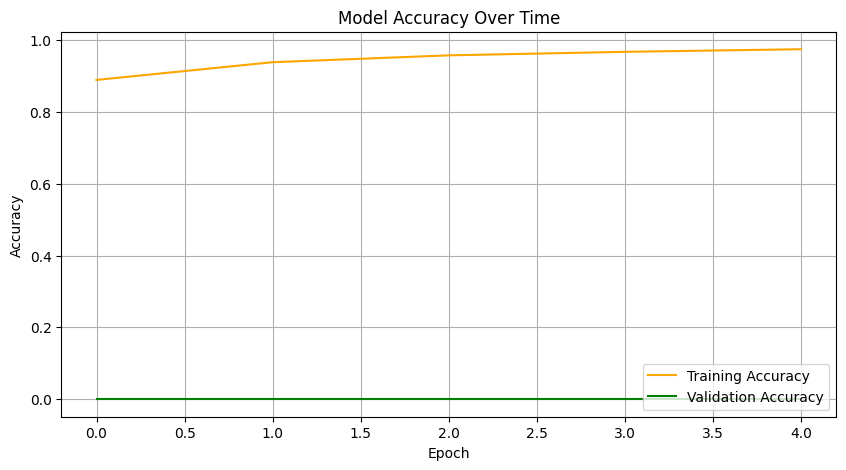

In [64]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
print("Starting Model Training...")

checkpoint = ModelCheckpoint(
    filepath="best_devnagari_model.keras",
    monitor='val_loss',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

# Train the model using model.fit()
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[checkpoint, early_stop]
)

print("\nModel training complete!")

plt.figure(figsize=(10, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy', color='orange')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')

plt.title('Model Accuracy Over Time')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Task 5: Evaluate the Model**

**Model Evaluation**

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [40]:
# Evaluate on the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

94/94 - 0s - 3ms/step - accuracy: 0.5967 - loss: 2.1439

Final Test Accuracy: 59.67%
Final Test Loss: 2.1439


**Task 6: Save and Load the Model**

**Model Saving and Loading**

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [41]:
# Save the model
model.save('devnagari_fcn_model.h5')
print("Model saved to 'devnagari_fcn_model.h5'")

# Load the model back
loaded_model = keras.models.load_model('devnagari_fcn_model.h5')

# Re-evaluate the loaded model to verify it works
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Loaded Model Accuracy: {loaded_acc*100:.2f}%")

Model saved to 'devnagari_fcn_model.h5'
Loaded Model Accuracy: 59.67%


**Task 7: Predictions**

**Making Predictions**

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


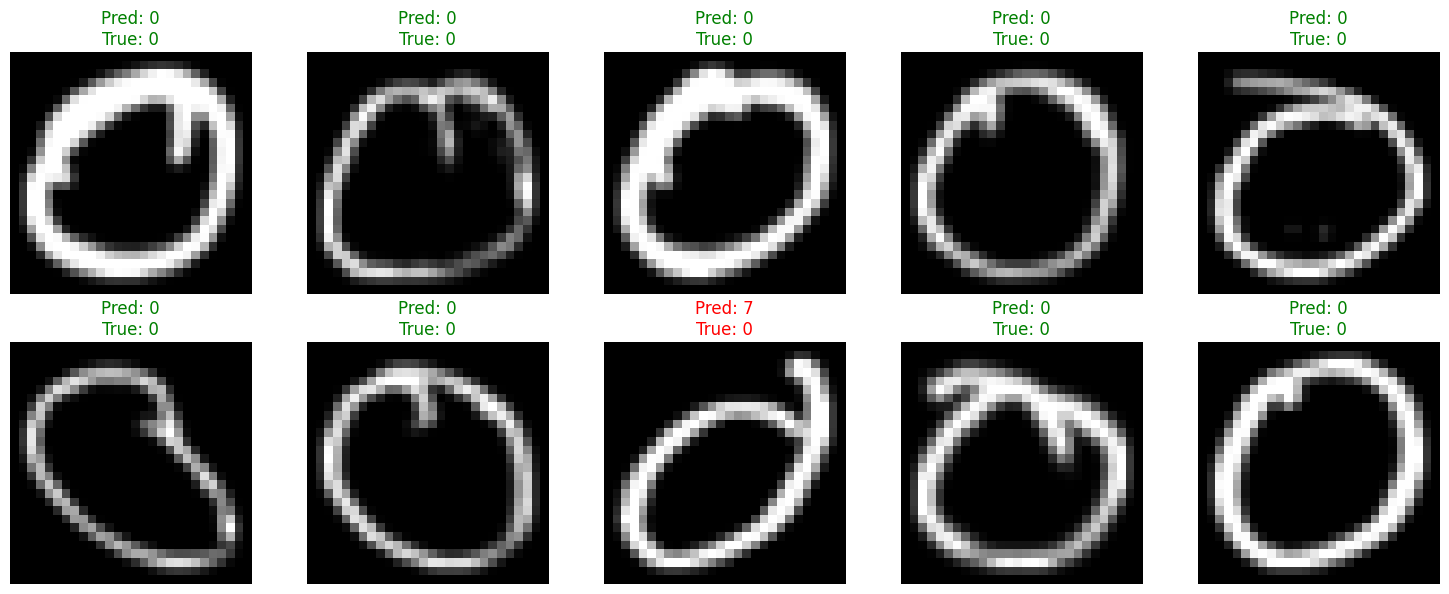

In [51]:
# Make predictions on test images
predictions = loaded_model.predict(x_test)

# Convert predicted probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)

true_labels = y_test

# Display the first 10 predictions vs actual labels
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    color = "green" if predicted_labels[i] == true_labels[i] else "red"

    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {true_labels[i]}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()
